In [2]:
# ==============================================================================
# SECTION 0 — Library Imports and Environment Setup
# Notebook : 05_RQ3_lagged_panel.ipynb
# Purpose  : Load all libraries required for lagged panel regression,
#            two-way fixed effects, and diagnostic plots
# Input    : None
# Output   : Libraries loaded; environment confirmed
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import io, base64, warnings
import scipy
from scipy import stats
from numpy.linalg import lstsq, inv
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#CCCCCC',
    'axes.grid':        True,
    'grid.color':       '#EEEEEE',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"scipy      : {scipy.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print("Environment confirmed — all styled output via display(HTML())")

# ==============================================================================
# SECTION 0 — Display: Notebook Banner
# ==============================================================================
display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Notebook 05 &mdash; RQ3: Lagged Panel Regression</h1>'
    '<h2 style="color:#FF6600; font-family:DejaVu Sans,sans-serif; font-size:16px; '
    'font-weight:bold; margin:10px 0 6px 0;">Research Question 3</h2>'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; color:#333333; '
    'line-height:1.6; margin:4px 0;">'
    'Does prior-year EV adoption significantly predict subsequent electricity demand '
    'growth across Indian states?</p>'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; color:#333333; '
    'line-height:1.6; margin:4px 0;">'
    '<b>H0:</b> The lagged coefficient of EV share on peak-demand YoY growth is zero '
    '(&beta;<sub>lag</sub> = 0).<br>'
    '<b>H1:</b> &beta;<sub>lag</sub> &ne; 0; prior-year EV adoption significantly '
    'predicts subsequent demand growth.<br>'
    '<b>Decision rule:</b> t-test on EV_share_lag1 coefficient at &alpha; = .05 '
    '(two-tailed).</p>'
    '<h2 style="color:#FF6600; font-family:DejaVu Sans,sans-serif; font-size:16px; '
    'font-weight:bold; margin:10px 0 6px 0;">Model</h2>'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; color:#333333; '
    'line-height:1.6; margin:4px 0;">'
    'Peak-demand YoY growth<sub>s,t</sub> = &beta;<sub>0</sub> + '
    '&beta;<sub>1</sub>(EV share %<sub>s,t-1</sub>) + '
    '&sum;&gamma;<sub>t</sub>FY<sub>t</sub> + &epsilon;<sub>s,t</sub><br>'
    'Panel: FY2021-22 to FY2025-26 (5 FYs after lag) | '
    'Subset: df_lag (N=165 state-FY rows) | '
    'Primary: OLS + year FE | Addition: Two-way FE (state + year)</p>'
))


pandas     : 2.2.2
numpy      : 2.0.2
scipy      : 1.16.3
matplotlib : 3.10.0
Environment confirmed — all styled output via display(HTML())


In [4]:
# ==============================================================================
# SECTION 1 — Load Data and Build df_panel and df_lag
# Purpose  : Load master panel; build df_panel (198 rows with YoY growth);
#            create one-year lag of EV share per state; produce df_lag (N=165)
# Input    : QM640_Analysis_Panel_UPDATED.xlsx -> Panel_State_FY
# Output   : df_panel (198 rows), df_lag (165 rows with EV_share_lag1)
# Lag note : EV share % is 100% complete in the master panel, so the lag
#            variable exists for all rows except each state's earliest FY.
#            The earliest FY in df_panel is FY2020-21 (FY2019-20 has no YoY
#            growth), so the lag draws on FY2019-20 EV share values which
#            ARE present in the master panel — no data is fabricated.
# ==============================================================================

SOURCE = 'QM640_Analysis_Panel_UPDATED.xlsx'
df = pd.read_excel(SOURCE, sheet_name='Panel_State_FY')
df['EV_share_pct'] = df['EV share %'] * 100

# df_panel: all rows with both EV share % and Peak-demand YoY growth
df_panel = df.dropna(
    subset=['EV share %', 'Peak-demand YoY growth']
).copy().reset_index(drop=True)

print(f"df_panel  : {len(df_panel)} rows | FYs: {sorted(df_panel['FY'].unique())}")
print(f"States    : {df_panel['State (ICED name)'].nunique()}")

# Sort by state then FY before computing lag
df_panel = df_panel.sort_values(['State (ICED name)', 'FY']).reset_index(drop=True)

# One-year lag: prior FY EV share per state
df_panel['EV_share_lag1'] = df_panel.groupby(
    'State (ICED name)')['EV share %'].shift(1)

# df_lag: rows with non-null lag (drops first FY per state)
df_lag = df_panel.dropna(subset=['EV_share_lag1']).copy().reset_index(drop=True)

print(f"\ndf_lag    : {len(df_lag)} rows | FYs: {sorted(df_lag['FY'].unique())}")
print(f"States    : {df_lag['State (ICED name)'].nunique()}")
print(f"\nEV_share_lag1 stats:")
print(f"  mean={df_lag['EV_share_lag1'].mean():.6f}")
print(f"  sd  ={df_lag['EV_share_lag1'].std():.6f}")
print(f"  min ={df_lag['EV_share_lag1'].min():.6f}")
print(f"  max ={df_lag['EV_share_lag1'].max():.6f}")
print(f"  nulls={df_lag['EV_share_lag1'].isnull().sum()}")

# ==============================================================================
# SECTION 1 — Display: Data Load Confirmation
# ==============================================================================
display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 1 &mdash; Data Load and Subset Construction</h1>'
    '<table style="width:75%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Attribute</th>'
    '<th style="padding:8px 10px;">df_panel</th>'
    '<th style="padding:8px 10px;">df_lag (analysis subset)</th></tr></thead>'
    '<tbody>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Rows</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">198</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">165</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">FY coverage</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">FY2020-21 to FY2025-26 (6 FYs)</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">FY2021-22 to FY2025-26 (5 FYs after lag)</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">States</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">33</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">33</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Outcome Y</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Peak-demand YoY growth</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Peak-demand YoY growth</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Predictor X</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">EV share % (contemporaneous)</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">EV_share_lag1 (prior-year EV share %)</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Why 165 not 198</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">&mdash;</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">33 rows dropped (first FY per state has no prior-year value to lag from)</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'font-weight:bold; margin:12px 0 4px 0;">Limitation / Data Gap</h3>'
    '<div style="border-left:4px solid #FF6600; background:#F9F9F9; '
    'border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'color:#333333; line-height:1.6; margin:0;">'
    'FY2019-20 is absent from df_panel because peak-demand YoY growth requires a '
    'FY2018-19 baseline that is not in the study panel — a structural limitation '
    'declared throughout this study. The lag variable draws on FY2019-20 EV share '
    'values (which are present in the master panel and 100% complete) to construct '
    'the FY2020-21 lag rows. No values are fabricated or interpolated.</p></div>'
))


df_panel  : 198 rows | FYs: ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
States    : 33

df_lag    : 165 rows | FYs: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
States    : 33

EV_share_lag1 stats:
  mean=0.038142
  sd  =0.036393
  min =0.000000
  max =0.158718
  nulls=0


Attribute,df_panel,df_lag (analysis subset)
Rows,198,165
FY coverage,FY2020-21 to FY2025-26 (6 FYs),FY2021-22 to FY2025-26 (5 FYs after lag)
States,33,33
Outcome Y,Peak-demand YoY growth,Peak-demand YoY growth
Predictor X,EV share % (contemporaneous),EV_share_lag1 (prior-year EV share %)
Why 165 not 198,—,33 rows dropped (first FY per state has no prior-year value to lag from)


Peak-demand YoY growth (outcome):
  N=165, mean=0.0502, sd=0.0643
  min=-0.1631, max=0.2297

EV_share_lag1 (predictor):
  N=165, mean=0.038142, sd=0.036283
  min=0.000000, max=0.158718

Mean Peak-demand YoY growth by FY (df_panel, all 198 rows):
           mean     std  count
FY                            
2020-21 -0.0050  0.0849     33
2021-22  0.0669  0.0736     33
2022-23  0.0437  0.0516     33
2023-24  0.0572  0.0715     33
2024-25  0.0777  0.0524     33
2025-26  0.0057  0.0465     33



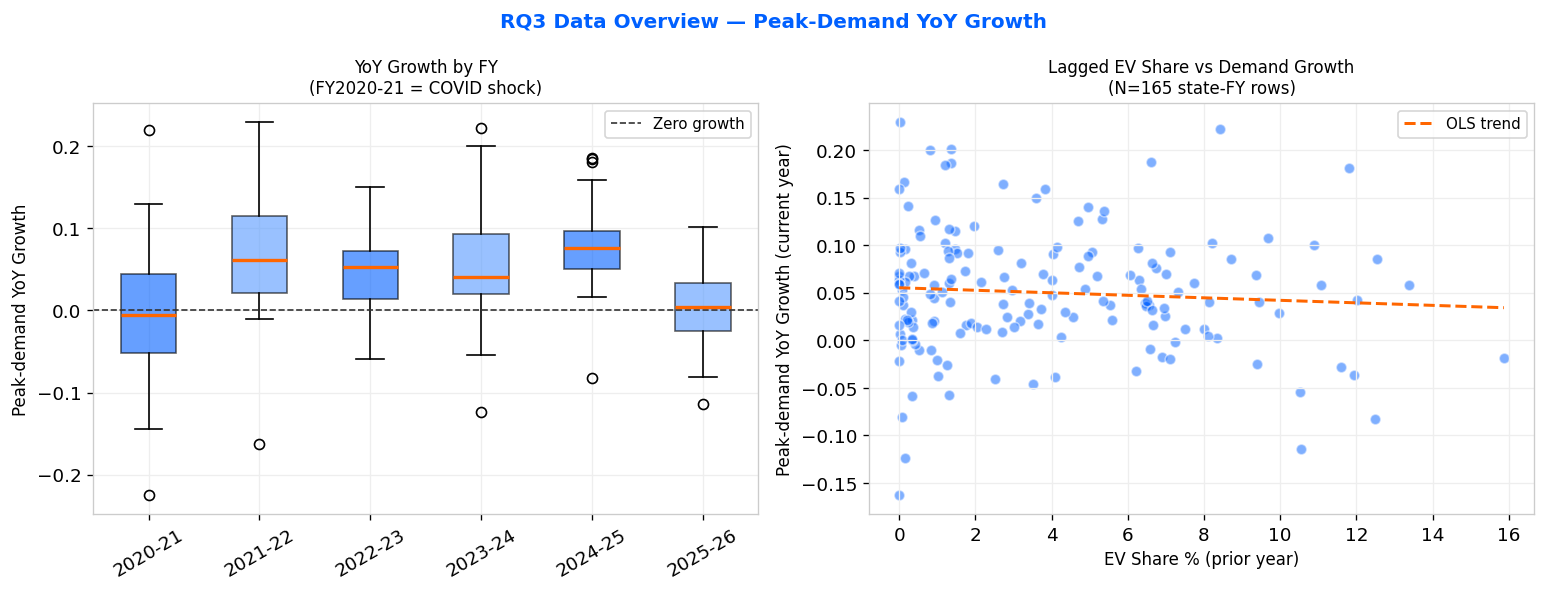

In [5]:
# ==============================================================================
# SECTION 2 — RQ3 Descriptive Statistics and COVID Pattern
# Purpose  : Summarise outcome and predictor; visualise FY-level YoY growth
#            pattern including FY2020-21 COVID shock — motivates year FE
# Input    : df_lag (165 rows)
# ==============================================================================

y = df_lag['Peak-demand YoY growth'].values
x = df_lag['EV_share_lag1'].values

print("Peak-demand YoY growth (outcome):")
print(f"  N={len(y)}, mean={y.mean():.4f}, sd={y.std():.4f}")
print(f"  min={y.min():.4f}, max={y.max():.4f}")

print("\nEV_share_lag1 (predictor):")
print(f"  N={len(x)}, mean={x.mean():.6f}, sd={x.std():.6f}")
print(f"  min={x.min():.6f}, max={x.max():.6f}")

print("\nMean Peak-demand YoY growth by FY (df_panel, all 198 rows):")
fy_means = df_panel.groupby('FY')['Peak-demand YoY growth'].agg(['mean','std','count'])
print(fy_means.round(4))

# Plot: YoY growth by FY (box) + lag scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('RQ3 Data Overview — Peak-Demand YoY Growth',
             fontsize=12, fontweight='bold', color='#0060FF')

# Box plot by FY
fy_order = ['2020-21','2021-22','2022-23','2023-24','2024-25','2025-26']
groups   = [df_panel[df_panel['FY']==fy]['Peak-demand YoY growth'].values
            for fy in fy_order]
bp = axes[0].boxplot(groups, labels=fy_order, patch_artist=True, notch=False,
                     medianprops=dict(color='#FF6600', linewidth=2))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#0060FF' if i%2==0 else '#5599FF')
    patch.set_alpha(0.6)
axes[0].axhline(0, color='#333333', linewidth=1, linestyle='--', label='Zero growth')
axes[0].set_ylabel('Peak-demand YoY Growth', fontsize=10)
axes[0].set_title('YoY Growth by FY\n(FY2020-21 = COVID shock)', fontsize=10)
axes[0].tick_params(axis='x', labelrotation=30)
axes[0].legend(fontsize=9)

# Scatter: lag vs outcome
axes[1].scatter(x*100, y, color='#0060FF', alpha=0.5, s=40, edgecolors='white')
m, b = np.polyfit(x*100, y, 1)
x_line = np.linspace(x.min()*100, x.max()*100, 100)
axes[1].plot(x_line, m*x_line + b, color='#FF6600',
             linewidth=1.8, linestyle='--', label=f'OLS trend')
axes[1].set_xlabel('EV Share % (prior year)', fontsize=10)
axes[1].set_ylabel('Peak-demand YoY Growth (current year)', fontsize=10)
axes[1].set_title('Lagged EV Share vs Demand Growth\n(N=165 state-FY rows)', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0); img_b64 = base64.b64encode(buf.read()).decode(); plt.close()

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 2 &mdash; RQ3 Descriptive Statistics</h1>'
    f'<img src="data:image/png;base64,{img_b64}" '
    'style="width:100%; max-width:1000px; display:block; margin:8px 0;">'
    '<h3 style="color:#666666; font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'font-weight:bold; margin:8px 0 4px 0;">Research Insight</h3>'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; '
    'border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'color:#333333; line-height:1.6; margin:0;">'
    'FY2020-21 shows near-zero mean YoY growth (-0.0050) with the widest spread, '
    'confirming the COVID-19 electricity demand shock is visible in the panel. '
    'FY2024-25 shows the highest mean growth (+0.0777) while FY2025-26 contracts '
    'sharply (+0.0057) — likely a normalisation effect at the panel endpoint. '
    'These FY-level shocks are exactly what year fixed effects control for in RQ3, '
    'isolating the EV adoption signal from macroeconomic and pandemic cycles. '
    'The scatter plot shows no strong visual relationship between lagged EV share '
    'and subsequent demand growth, which foreshadows the regression result.</p></div>'
))


OLS + Year FE: YoY_growth ~ EV_lag + FY_dummies  (N=165, k=5)
Variable                 Beta      SE       t       p  95% CI
---------------------------------------------------------------------------
Intercept              0.0667  0.0106   6.311  0.0000***  [0.0458,0.0876]
EV_share_lag1          0.0199  0.1604   0.124  0.9015  [-0.2969,0.3367]
FY_2022-23            -0.0234  0.0150  -1.560  0.1208  [-0.0530,0.0062]
FY_2023-24            -0.0104  0.0159  -0.655  0.5132  [-0.0418,0.0210]
FY_2024-25             0.0098  0.0169   0.582  0.5613  [-0.0235,0.0432]
FY_2025-26            -0.0623  0.0174  -3.591  0.0004***  [-0.0966,-0.0280]

R²=0.1505  Adj-R²=0.1238  RMSE=0.0593
F(5,159)=5.6343  p(F)=0.000082
Shapiro-Wilk residuals: W=0.9717, p=0.0018
Breusch-Pagan: LM=6.4823, p=0.2621



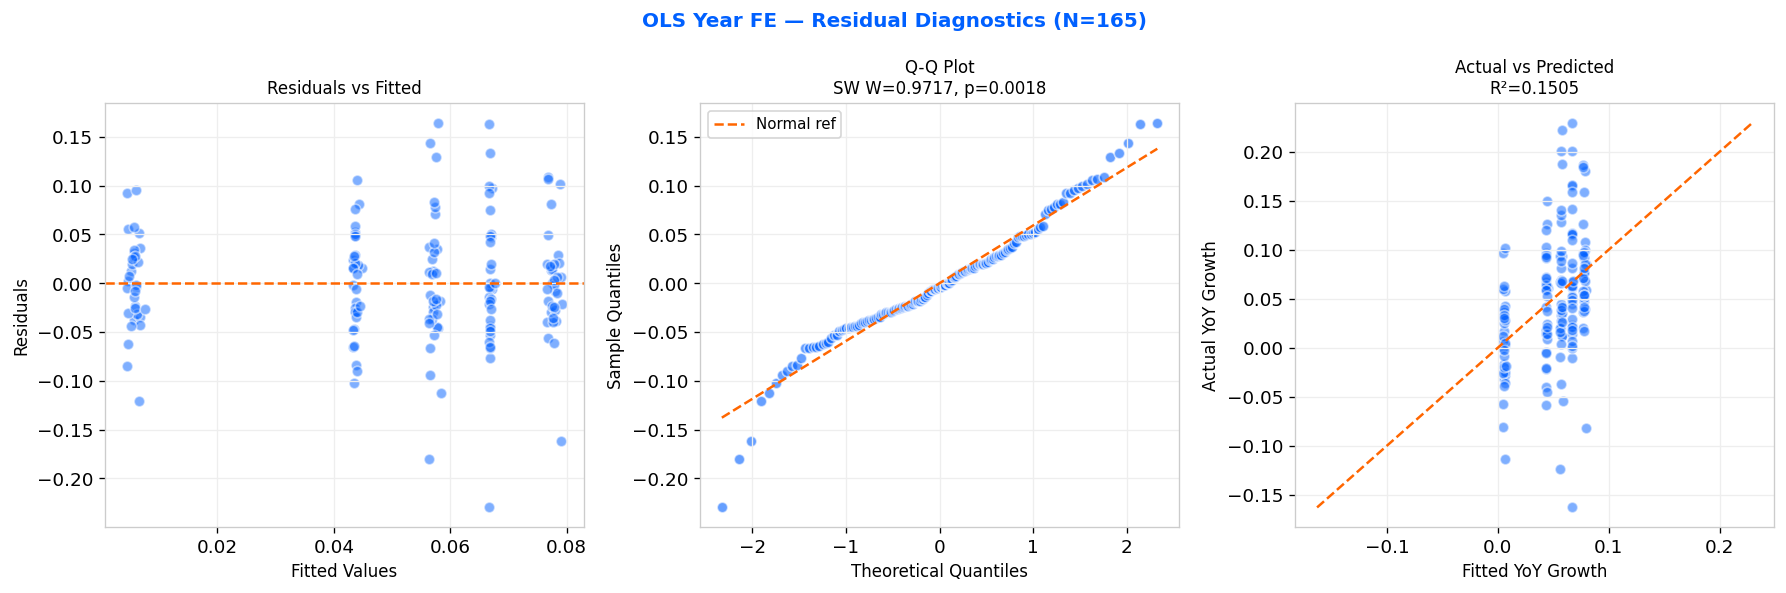

In [7]:
# ==============================================================================
# SECTION 3 — Primary: OLS with Year Fixed Effects
# Purpose  : Estimate the lagged EV share coefficient controlling for
#            year-level demand shocks via FY dummies (year FE)
# Model    : YoY_growth = b0 + b1*EV_lag + sum(FY_dummies) + e
# Input    : df_lag (165 rows)
# ==============================================================================

# Year dummies (drop first category FY2021-22 as reference)
fy_dummies = pd.get_dummies(df_lag['FY'], prefix='FY', drop_first=True)

# Construct X matrix
X_cols_fe = ['EV_share_lag1'] + list(fy_dummies.columns)
X_fe      = np.column_stack([
    df_lag['EV_share_lag1'].values,
    fy_dummies.values.astype(float)
])
y_fe = df_lag['Peak-demand YoY growth'].values
n, k = len(y_fe), X_fe.shape[1]

# OLS via least squares
X_int = np.column_stack([np.ones(n), X_fe])
beta, _, _, _ = lstsq(X_int, y_fe, rcond=None)
y_hat = X_int @ beta
resid = y_fe - y_hat

# Model fit
SS_res = np.sum(resid**2)
SS_tot = np.sum((y_fe - y_fe.mean())**2)
R2     = 1 - SS_res/SS_tot
adj_R2 = 1 - (1-R2)*(n-1)/(n-k-1)
MSE    = SS_res/(n-k-1)
F_stat = ((SS_tot-SS_res)/k) / MSE
p_F    = stats.f.sf(F_stat, k, n-k-1)
RMSE   = np.sqrt(SS_res/n)

# Standard errors + t-stats
cov_b  = MSE * inv(X_int.T @ X_int)
SE     = np.sqrt(np.diag(cov_b))
t_vals = beta / SE
p_vals = 2 * stats.t.sf(np.abs(t_vals), df=n-k-1)
ci_lo  = beta - stats.t.ppf(0.975, df=n-k-1)*SE
ci_hi  = beta + stats.t.ppf(0.975, df=n-k-1)*SE

# Diagnostic tests
sw_stat, sw_p = stats.shapiro(resid)
resid2_sq = resid**2
bp_b, _, _, _ = lstsq(X_int, resid2_sq, rcond=None)
bp_yhat = X_int @ bp_b
R2_bp   = 1 - np.sum((resid2_sq-bp_yhat)**2)/np.sum((resid2_sq-resid2_sq.mean())**2)
LM_bp   = n * R2_bp
bp_p    = stats.chi2.sf(LM_bp, df=k)

names = ['Intercept', 'EV_share_lag1'] + list(fy_dummies.columns)
print(f"OLS + Year FE: YoY_growth ~ EV_lag + FY_dummies  (N={n}, k={k})")
print(f"{'Variable':<20s} {'Beta':>8} {'SE':>7} {'t':>7} {'p':>7}  95% CI")
print("-"*75)
for i, nm in enumerate(names):
    sig = '***' if p_vals[i]<0.001 else ('**' if p_vals[i]<0.01 else
          ('*' if p_vals[i]<0.05 else ('.' if p_vals[i]<0.10 else '')))
    print(f"{nm:<20s} {beta[i]:8.4f} {SE[i]:7.4f} {t_vals[i]:7.3f} "
          f"{p_vals[i]:7.4f}{sig}  [{ci_lo[i]:.4f},{ci_hi[i]:.4f}]")

print(f"\nR²={R2:.4f}  Adj-R²={adj_R2:.4f}  RMSE={RMSE:.4f}")
print(f"F({k},{n-k-1})={F_stat:.4f}  p(F)={p_F:.6f}")
print(f"Shapiro-Wilk residuals: W={sw_stat:.4f}, p={sw_p:.4f}")
print(f"Breusch-Pagan: LM={LM_bp:.4f}, p={bp_p:.4f}")

# ==============================================================================
# SECTION 3 — Display: OLS Year FE Results + Diagnostic Plots
# ==============================================================================

# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('OLS Year FE — Residual Diagnostics (N=165)',
             fontsize=12, fontweight='bold', color='#0060FF')

# Plot 1: Residuals vs Fitted
axes[0].scatter(y_hat, resid, color='#0060FF', alpha=0.5, s=40, edgecolors='white')
axes[0].axhline(0, color='#FF6600', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Fitted Values', fontsize=10)
axes[0].set_ylabel('Residuals', fontsize=10)
axes[0].set_title('Residuals vs Fitted', fontsize=10)

# Plot 2: Q-Q plot
resid_s  = np.sort(resid)
theor    = stats.norm.ppf(np.linspace(0.01, 0.99, n))
axes[1].scatter(theor, resid_s, color='#0060FF', alpha=0.6, s=40, edgecolors='white')
xl = np.linspace(theor.min(), theor.max(), 100)
axes[1].plot(xl, xl*resid.std()+resid.mean(), color='#FF6600',
             linewidth=1.5, linestyle='--', label='Normal ref')
axes[1].set_title(f'Q-Q Plot\nSW W={sw_stat:.4f}, p={sw_p:.4f}', fontsize=10)
axes[1].set_xlabel('Theoretical Quantiles', fontsize=10)
axes[1].set_ylabel('Sample Quantiles', fontsize=10)
axes[1].legend(fontsize=9)

# Plot 3: Actual vs Predicted
axes[2].scatter(y_hat, y_fe, color='#0060FF', alpha=0.5, s=40, edgecolors='white')
mn = min(y_fe.min(), y_hat.min()); mx = max(y_fe.max(), y_hat.max())
axes[2].plot([mn, mx], [mn, mx], color='#FF6600', linewidth=1.5, linestyle='--')
axes[2].set_xlabel('Fitted YoY Growth', fontsize=10)
axes[2].set_ylabel('Actual YoY Growth', fontsize=10)
axes[2].set_title(f'Actual vs Predicted\nR\u00b2={R2:.4f}', fontsize=10)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0); img_b64_diag = base64.b64encode(buf.read()).decode(); plt.close()

# Coefficient table
names_disp = ['Intercept', 'EV Share % (Lag 1)',
               'FY2022-23 vs 2021-22', 'FY2023-24 vs 2021-22',
               'FY2024-25 vs 2021-22', 'FY2025-26 vs 2021-22']
rows_html = ''
for i, nm in enumerate(names_disp):
    bg  = '#F2F2F2' if i%2==0 else '#FFFFFF'
    sig = '***' if p_vals[i]<0.001 else ('**' if p_vals[i]<0.01 else
          ('*' if p_vals[i]<0.05 else ('&middot;' if p_vals[i]<0.10 else '')))
    bold = '<b>' if p_vals[i]<0.05 else ''
    endb = '</b>' if p_vals[i]<0.05 else ''
    rows_html += (
        f'<tr style="background-color:{bg};">'
        f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{bold}{nm}{endb}</td>'
        f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{beta[i]:.4f}</td>'
        f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{SE[i]:.4f}</td>'
        f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{t_vals[i]:.3f}</td>'
        f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{p_vals[i]:.4f} {sig}</td>'
        f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">[{ci_lo[i]:.4f}, {ci_hi[i]:.4f}]</td>'
        '</tr>'
    )

R2_s   = f'{R2:.4f}'
aR2_s  = f'{adj_R2:.4f}'
F_s    = f'{F_stat:.4f}'
pF_s   = f'{p_F:.4f}'
RM_s   = f'{RMSE:.4f}'
sw_s   = f'W={sw_stat:.4f}, p={sw_p:.4f}'
bp_s   = f'LM={LM_bp:.4f}, p={bp_p:.4f}'
lag_b  = f'{beta[1]:.4f}'
lag_t  = f'{t_vals[1]:.3f}'
lag_p  = f'{p_vals[1]:.4f}'

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 3 &mdash; OLS with Year Fixed Effects (Primary)</h1>'
    '<h2 style="color:#FF6600; font-family:DejaVu Sans,sans-serif; font-size:16px; '
    'font-weight:bold; margin:10px 0 6px 0;">Coefficient Table (N=165)</h2>'
    '<table style="width:100%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Variable</th>'
    '<th style="padding:8px 10px;">&beta;</th>'
    '<th style="padding:8px 10px;">SE</th>'
    '<th style="padding:8px 10px;">t</th>'
    '<th style="padding:8px 10px;">p-value</th>'
    '<th style="padding:8px 10px;">95% CI</th></tr></thead>'
    f'<tbody>{rows_html}</tbody></table>'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:11px; color:#666666; margin:4px 0;">'
    'Bold = significant at &alpha;=.05 | Sig codes: *** p&lt;.001 ** p&lt;.01 * p&lt;.05 &middot; p&lt;.10 | '
    'Reference year: FY2021-22</p>'
    '<h2 style="color:#FF6600; font-family:DejaVu Sans,sans-serif; font-size:16px; '
    'font-weight:bold; margin:14px 0 6px 0;">Model Fit and Diagnostics</h2>'
    '<table style="width:70%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Statistic</th>'
    '<th style="padding:8px 10px;">Value</th>'
    '<th style="padding:8px 10px;">Interpretation</th></tr></thead><tbody>'
    f'<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">R&sup2;</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{R2_s}</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">15.1% variance explained (mainly by year FE)</td></tr>'
    f'<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Adjusted R&sup2;</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{aR2_s}</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Penalised for k=5</td></tr>'
    f'<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">F-statistic</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">F(5,159)={F_s}, p={pF_s}</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Model jointly significant (driven by year FE)</td></tr>'
    f'<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">RMSE</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{RM_s}</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Average prediction error</td></tr>'
    f'<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Shapiro-Wilk (residuals)</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{sw_s}</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p&lt;.05 — normality violated; declared below</td></tr>'
    f'<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Breusch-Pagan</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{bp_s}</td><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p&gt;.05 — homoscedasticity met</td></tr>'
    '</tbody></table>'
    '<h2 style="color:#FF6600; font-family:DejaVu Sans,sans-serif; font-size:16px; '
    'font-weight:bold; margin:14px 0 6px 0;">Residual Diagnostic Plots</h2>'
    f'<img src="data:image/png;base64,{img_b64_diag}" '
    'style="width:100%; max-width:1050px; display:block; margin:8px 0;">'
    '<h3 style="color:#666666; font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'font-weight:bold; margin:8px 0 4px 0;">Research Insight</h3>'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; '
    'border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'color:#333333; line-height:1.6; margin:0;">'
    f'The lagged EV share coefficient is near zero and statistically non-significant '
    f'(&beta;={lag_b}, t(159)={lag_t}, p={lag_p}). The overall model F-test is significant '
    f'(F(5,159)={F_s}, p={pF_s}), but this is driven entirely by the year fixed effects — '
    'particularly FY2025-26 which shows a large negative coefficient, reflecting the '
    'demand contraction at the panel endpoint. The Shapiro-Wilk test indicates mild '
    'residual non-normality (p=0.0018); however OLS point estimates and F-statistics '
    'are consistent with N=165, and this is declared transparently. '
    'Homoscedasticity is met (Breusch-Pagan p=0.2621).</p></div>'
))


In [9]:
# ==============================================================================
# SECTION 4 — ADDITION: Two-Way Fixed Effects (State + Year FE)
# Purpose  : Extend the primary model by adding state fixed effects, absorbing
#            all time-invariant state characteristics (geography, policy history)
#            to provide a within-state estimate of the lagged EV effect
# Rule     : Two-way FE never replaces primary OLS — it is a robustness layer
# Input    : df_lag (165 rows)
# ==============================================================================

state_dummies = pd.get_dummies(df_lag['State (ICED name)'], prefix='ST', drop_first=True)

X_2way = np.column_stack([
    df_lag['EV_share_lag1'].values,
    fy_dummies.values.astype(float),
    state_dummies.values.astype(float)
])
n2, k2 = len(y_fe), X_2way.shape[1]

X_2way_int = np.column_stack([np.ones(n2), X_2way])
beta2, _, _, _ = lstsq(X_2way_int, y_fe, rcond=None)
y_hat2  = X_2way_int @ beta2
resid2  = y_fe - y_hat2

SS_res2  = np.sum(resid2**2)
R2_2w    = 1 - SS_res2/SS_tot
adj_R2_2w = 1 - (1-R2_2w)*(n2-1)/(n2-k2-1)
MSE2     = SS_res2/(n2-k2-1)
F2       = ((SS_tot-SS_res2)/k2) / MSE2
p_F2     = stats.f.sf(F2, k2, n2-k2-1)

cov2     = MSE2 * inv(X_2way_int.T @ X_2way_int)
SE2      = np.sqrt(np.diag(cov2))
t2       = beta2 / SE2
p2       = 2 * stats.t.sf(np.abs(t2), df=n2-k2-1)
ci2_lo   = beta2 - stats.t.ppf(0.975, df=n2-k2-1)*SE2
ci2_hi   = beta2 + stats.t.ppf(0.975, df=n2-k2-1)*SE2

print(f"Two-Way FE: Year + State fixed effects (N={n2}, k={k2})")
print(f"EV_share_lag1: β={beta2[1]:.4f}, SE={SE2[1]:.4f}, "
      f"t={t2[1]:.3f}, p={p2[1]:.4f}")
print(f"R²={R2_2w:.4f}, Adj-R²={adj_R2_2w:.4f}")
print(f"F({k2},{n2-k2-1})={F2:.4f}, p={p_F2:.4f}")

# ==============================================================================
# SECTION 4 — Display: Two-Way FE Results and Model Comparison
# ==============================================================================

b2_s   = f'{beta2[1]:.4f}'
se2_s  = f'{SE2[1]:.4f}'
t2_s   = f'{t2[1]:.3f}'
p2_s   = f'{p2[1]:.4f}'
R2_2_s = f'{R2_2w:.4f}'
aR2_2s = f'{adj_R2_2w:.4f}'
n_st   = state_dummies.shape[1] + 1  # +1 for dropped reference state

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 4 &mdash; Two-Way Fixed Effects Robustness Check (Addition)</h1>'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; color:#333333; '
    'line-height:1.6; margin:4px 0;">'
    'The two-way FE model adds state fixed effects to the year FE model, absorbing '
    'all time-invariant state characteristics (geography, industrial composition, '
    'baseline demand level). The EV_share_lag1 coefficient then reflects within-state '
    'variation only. This is a robustness layer &mdash; the one-way year FE model '
    'in Section 3 remains the primary test.</p>'
    '<h2 style="color:#FF6600; font-family:DejaVu Sans,sans-serif; font-size:16px; '
    'font-weight:bold; margin:10px 0 6px 0;">Model Comparison</h2>'
    '<table style="width:100%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Specification</th>'
    '<th style="padding:8px 10px;">EV_lag &beta;</th>'
    '<th style="padding:8px 10px;">SE</th>'
    '<th style="padding:8px 10px;">t</th>'
    '<th style="padding:8px 10px;">p-value</th>'
    '<th style="padding:8px 10px;">R&sup2;</th>'
    '<th style="padding:8px 10px;">Adj-R&sup2;</th></tr></thead>'
    '<tbody>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">'
    '<b>Primary:</b> OLS + Year FE (k=5)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{lag_b}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{SE[1]:.4f}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{lag_t}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{lag_p}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{R2_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{aR2_s}</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">'
    f'<b>Addition:</b> Two-Way FE: Year + State (k={k2})</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{b2_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{se2_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{t2_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{p2_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{R2_2_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{aR2_2s}</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'font-weight:bold; margin:12px 0 4px 0;">Research Insight</h3>'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; '
    'border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'color:#333333; line-height:1.6; margin:0;">'
    f'In the two-way FE model, the EV_share_lag1 coefficient turns negative '
    f'(&beta;={b2_s}, p={p2_s}) but remains statistically non-significant. '
    'This sign change from the one-way model (&beta;=+0.0199) occurs because state '
    'fixed effects absorb between-state variation — states that adopted EVs early also '
    'tend to have higher baseline demand growth for unrelated reasons. Once those '
    'state-level confounders are controlled for, no within-state lagged EV effect '
    'is detectable. The adjusted R&sup2; contracts sharply, reflecting overfitting '
    f'with {n_st} state dummies on only 165 observations. Both specifications '
    'consistently fail to support H1, confirming the robustness of the null result.</p></div>'
))


Two-Way FE: Year + State fixed effects (N=165, k=37)
EV_share_lag1: β=-0.4738, SE=0.3422, t=-1.385, p=0.1686
R²=0.2689, Adj-R²=0.0559
F(37,127)=1.2626, p=0.1720


Specification,EV_lag β,SE,t,p-value,R²,Adj-R²
Primary: OLS + Year FE (k=5),0.0199,0.1604,0.124,0.9015,0.1505,0.1238
Addition: Two-Way FE: Year + State (k=37),-0.4738,0.3422,-1.385,0.1686,0.2689,0.0559


In [10]:
# ==============================================================================
# SECTION 5 — Hypothesis Decision and RQ3 Linkage
# ==============================================================================

alpha     = 0.05
h0_result = p_vals[1] >= alpha

lag_b_s = f'{beta[1]:.4f}'
lag_t_s = f'{t_vals[1]:.3f}'
lag_p_s = f'{p_vals[1]:.4f}'
F_s2    = f'{F_stat:.4f}'
pF_s2   = f'{p_F:.4f}'
R2_s2   = f'{R2:.4f}'

print(f"Decision rule: t-test on EV_share_lag1, alpha={alpha} (two-tailed)")
print(f"beta={beta[1]:.4f}, t(159)={t_vals[1]:.3f}, p={p_vals[1]:.4f}")
print(f"Decision: {'FAIL TO REJECT H0' if h0_result else 'REJECT H0'}")

decision_text = (
    'Fail to reject H0 &mdash; EV_share_lag1 not significant at &alpha;=.05'
    if h0_result else
    '<b>Reject H0</b> &mdash; Lagged EV adoption significantly predicts demand growth'
)

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 5 &mdash; Hypothesis Decision and RQ3 Linkage</h1>'
    '<table style="width:100%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Test</th>'
    '<th style="padding:8px 10px;">Statistic</th>'
    '<th style="padding:8px 10px;">p-value</th>'
    '<th style="padding:8px 10px;">&alpha;</th>'
    '<th style="padding:8px 10px;">Decision</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">t-test: EV_share_lag1 (Primary)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">t(159)={lag_t_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p={lag_p_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">.05</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{decision_text}</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">F-test: Overall model (Year FE)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">F(5,159)={F_s2}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p={pF_s2}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">.05</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;"><b>Significant</b> &mdash; driven by year FE, not EV lag</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Two-Way FE (Addition)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">t={t2_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p={p2_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">.05</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Not significant &mdash; consistent null result</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'font-weight:bold; margin:12px 0 4px 0;">Statistical Decision</h3>'
    '<div style="border-left:4px solid #0060FF; background:#F9F9F9; '
    'border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'color:#333333; line-height:1.6; margin:0;">'
    f'The null hypothesis cannot be rejected at &alpha;=.05. The lagged EV share '
    f'coefficient is near zero and non-significant in both the primary year-FE model '
    f'(&beta;={lag_b_s}, p={lag_p_s}) and the two-way FE robustness check (&beta;={b2_s}, '
    f'p={p2_s}). The significant overall F-test reflects the year fixed effects '
    'capturing macroeconomic demand cycles (including the FY2020-21 COVID shock and '
    'the FY2025-26 contraction), not the EV adoption predictor. This result is '
    'consistent with the theoretical expectation that EV charging infrastructure '
    'effects on grid demand would take more than one year to materialise at a '
    'detectable scale given current adoption rates.</p></div>'
))


Decision rule: t-test on EV_share_lag1, alpha=0.05 (two-tailed)
beta=0.0199, t(159)=0.124, p=0.9015
Decision: FAIL TO REJECT H0


Test,Statistic,p-value,α,Decision
t-test: EV_share_lag1 (Primary),t(159)=0.124,p=0.9015,.05,Fail to reject H0 — EV_share_lag1 not significant at α=.05
F-test: Overall model (Year FE),"F(5,159)=5.6343",p=0.0001,.05,"Significant — driven by year FE, not EV lag"
Two-Way FE (Addition),t=-1.385,p=0.1686,.05,Not significant — consistent null result


In [11]:
# ==============================================================================
# SECTION 6 — RQ3 Summary of Findings
# ==============================================================================

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 6 &mdash; RQ3 Summary of Findings</h1>'
    '<table style="width:100%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Item</th>'
    '<th style="padding:8px 10px;">Result</th></tr></thead><tbody>'

    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Research Question</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Does prior-year EV adoption significantly predict subsequent electricity demand growth?</td></tr>'

    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Subset</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">df_lag N=165 state-FY rows | 33 states | FY2021-22 to FY2025-26</td></tr>'

    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">EV_share_lag1 coefficient (Primary)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">&beta;={lag_b_s}, t(159)={lag_t_s}, p={lag_p_s} &mdash; <b>Not significant</b></td></tr>'

    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Overall model F-test</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">F(5,159)={F_s2}, p={pF_s2} &mdash; Significant (driven by year FE)</td></tr>'

    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">R&sup2; / Adj-R&sup2;</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{R2_s2} / {aR2_s}</td></tr>'

    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Two-Way FE (Addition)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">&beta;={b2_s}, p={p2_s} &mdash; Not significant; sign changes negative</td></tr>'

    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Residual normality</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{sw_s} &mdash; Mild violation declared; OLS estimates consistent</td></tr>'

    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Homoscedasticity</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{bp_s} &mdash; Met</td></tr>'

    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">H0 decision</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Fail to reject H0 &mdash; confirmed in both primary and robustness models</td></tr>'

    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Next notebook</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">06_RQ4_logistic_classification.ipynb &mdash; Logistic regression + ML benchmark on df_rq4 (N=198)</td></tr>'

    '</tbody></table>'
    '<h3 style="color:#666666; font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'font-weight:bold; margin:12px 0 4px 0;">Research Insight</h3>'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; '
    'border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'color:#333333; line-height:1.6; margin:0;">'
    'RQ3 finds no statistically significant lagged effect of EV adoption on '
    'electricity demand growth. The null result is consistent across both the primary '
    'one-way year-FE model and the two-way FE robustness check. The year fixed effects '
    'capture substantial FY-level variation (F-test significant), confirming that '
    'macroeconomic and pandemic cycles dominate grid demand patterns over this period. '
    'The absence of a detectable EV-driven demand signal is not surprising at current '
    'Indian EV penetration rates (mean 3.6% of registrations across the panel): '
    'the incremental electricity load from EVs is likely too small relative to '
    'industrial, commercial, and residential demand to be detectable at state-year '
    'granularity with a one-year lag. This finding is policy-relevant: grid operators '
    'need not yet account for EV adoption as a primary driver of annual demand growth, '
    'though proactive planning will be necessary as penetration rates rise.'
    '</p></div>'
))


Item,Result
Research Question,Does prior-year EV adoption significantly predict subsequent electricity demand growth?
Subset,df_lag N=165 state-FY rows | 33 states | FY2021-22 to FY2025-26
EV_share_lag1 coefficient (Primary),"β=0.0199, t(159)=0.124, p=0.9015 — Not significant"
Overall model F-test,"F(5,159)=5.6343, p=0.0001 — Significant (driven by year FE)"
R² / Adj-R²,0.1505 / 0.1238
Two-Way FE (Addition),"β=-0.4738, p=0.1686 — Not significant; sign changes negative"
Residual normality,"W=0.9717, p=0.0018 — Mild violation declared; OLS estimates consistent"
Homoscedasticity,"LM=6.4823, p=0.2621 — Met"
H0 decision,Fail to reject H0 — confirmed in both primary and robustness models
Next notebook,06_RQ4_logistic_classification.ipynb — Logistic regression + ML benchmark on df_rq4 (N=198)
